In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Linear SVM Kernel

In [55]:
#Create a synthetic dataset
from sklearn.datasets import make_classification
X,y=make_classification(n_samples=1000,n_features=2,n_classes=2,n_clusters_per_class=1,n_redundant=0)

In [56]:
X

array([[ 0.8062999 , -0.40656564],
       [ 3.47585261,  3.88065377],
       [ 1.29292068,  1.12193796],
       ...,
       [-1.84174701, -0.44720962],
       [ 0.14338366, -0.41772526],
       [ 1.16314568,  0.15953558]])

In [57]:
pd.DataFrame(X)

,0,1
0,0.806300,-0.406566
1,3.475853,3.880654
2,1.292921,1.121938
3,-1.066501,-1.903535
4,-3.025438,0.118343
...,...,...
995,-0.346389,-1.136541
996,0.603305,1.681353
997,-1.841747,-0.447210
998,0.143384,-0.417725


In [58]:
y

array([1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1,

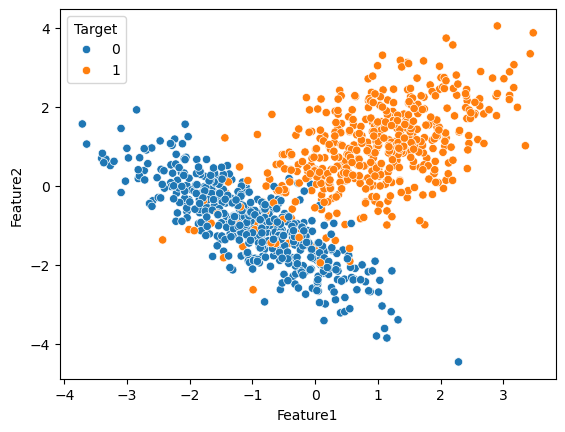

In [59]:
df = pd.DataFrame(X, columns=["Feature1", "Feature2"])
df["Target"] = y

sns.scatterplot(data=df, x="Feature1", y="Feature2", hue="Target")
plt.show()

In [60]:
#Split the data
from sklearn.model_selection import train_test_split
X_Train,X_Test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [61]:
#Train the data model
from sklearn.svm import SVC
svc=SVC(kernel='linear')

In [62]:
svc.fit(X_Train,y_train)

SVC(kernel='linear')

In [63]:
y_pred=svc.predict(X_Test)

In [64]:
#Performance metrics
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
cm=confusion_matrix(y_test,y_pred)
print(cm)

score=accuracy_score(y_test,y_pred)
print(score)

print(classification_report(y_test,y_pred))

[[124   2]
 [ 15 109]]
0.932
              precision    recall  f1-score   support

           0       0.89      0.98      0.94       126
           1       0.98      0.88      0.93       124

    accuracy                           0.93       250
   macro avg       0.94      0.93      0.93       250
weighted avg       0.94      0.93      0.93       250



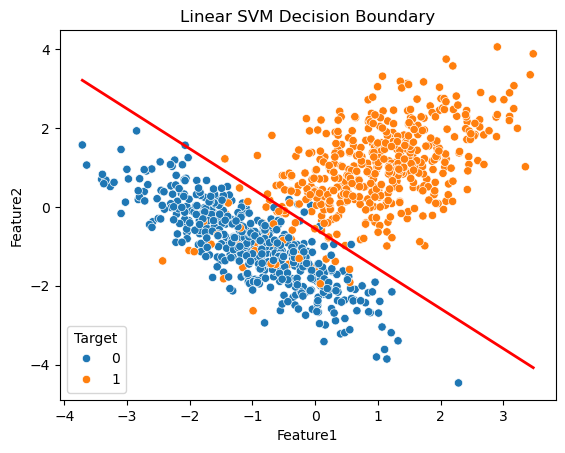

In [65]:
df = pd.DataFrame(X, columns=["Feature1", "Feature2"])
df["Target"] = y

sns.scatterplot(data=df, x="Feature1", y="Feature2", hue="Target")

# -------- Decision Boundary --------
w = svc.coef_[0]
b = svc.intercept_[0]

x_points = np.linspace(df["Feature1"].min(), df["Feature1"].max(), 100)

# Decision boundary equation
y_points = -(w[0] * x_points + b) / w[1]

plt.plot(x_points, y_points, color="red", linewidth=2)

plt.title("Linear SVM Decision Boundary")
plt.show()

## RBF SVM Kernel

In [66]:
#create a new Dataset
from sklearn.datasets import make_classification
X1,y1=make_classification(n_samples=1000,n_classes=2,n_features=2,n_clusters_per_class=2,n_redundant=0,random_state=1)

In [67]:
X1

array([[ 0.86341137, -0.91235445],
       [-0.53099717,  0.90118241],
       [ 0.98277596, -1.59111159],
       ...,
       [ 1.33019532,  3.72180951],
       [-1.01084076,  0.42633933],
       [-1.00873243,  1.24540194]])

In [68]:
y1

array([1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0,

In [69]:
#visualize the dataset
df=pd.DataFrame(X1,columns=['feature 1','feature 2'])
df["Target"]=y1
df

,feature 1,feature 2,Target
0,0.863411,-0.912354,1
1,-0.530997,0.901182,0
2,0.982776,-1.591112,0
3,-1.032039,-0.801162,0
4,3.620555,-0.098876,1
...,...,...,...
995,2.143260,2.223026,1
996,1.425043,-0.236500,1
997,1.330195,3.721810,1
998,-1.010841,0.426339,0


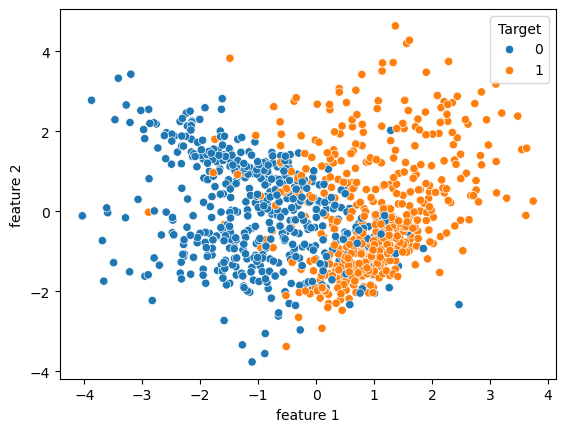

In [70]:
sns.scatterplot(data=df,x='feature 1',y='feature 2',hue='Target')
plt.show()

In [71]:
from sklearn.model_selection import train_test_split
X1_Train,X1_Test,y1_train,y1_test=train_test_split(X1,y1,test_size=0.25,random_state=42)

In [72]:
from sklearn.svm import SVC
svc_lin=SVC(kernel='linear')
svc_lin.fit(X1_Train,y1_train)

SVC(kernel='linear')

In [73]:
lin_y_pred=svc_lin.predict(X1_Test)

In [74]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
cm=confusion_matrix(y1_test,lin_y_pred)
print(cm)

score=accuracy_score(y1_test,lin_y_pred)
print(score)

print(classification_report(y1_test,lin_y_pred))

[[107  18]
 [ 13 112]]
0.876
              precision    recall  f1-score   support

           0       0.89      0.86      0.87       125
           1       0.86      0.90      0.88       125

    accuracy                           0.88       250
   macro avg       0.88      0.88      0.88       250
weighted avg       0.88      0.88      0.88       250



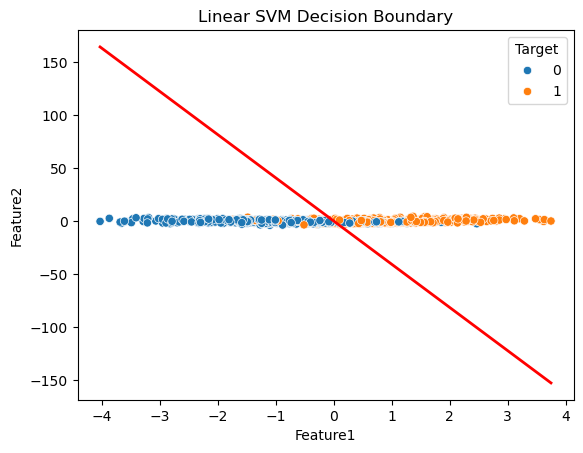

In [75]:
df = pd.DataFrame(X1, columns=["Feature1", "Feature2"])
df["Target"] = y1

sns.scatterplot(data=df, x="Feature1", y="Feature2", hue="Target")

# -------- Decision Boundary --------
w = svc_lin.coef_[0]
b = svc_lin.intercept_[0]

x_points = np.linspace(df["Feature1"].min(), df["Feature1"].max(), 100)

# Decision boundary equation
y_points = -(w[0] * x_points + b) / w[1]

plt.plot(x_points, y_points, color="red", linewidth=2)

plt.title("Linear SVM Decision Boundary")
plt.show()

In [76]:
svcRBF=SVC(kernel='rbf')
svcRBF.fit(X1_Train,y1_train)

SVC()

In [77]:
rbf_y_pred=svcRBF.predict(X1_Test)

In [79]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
cm1=confusion_matrix(y1_test,rbf_y_pred)
print(cm1)

score1=accuracy_score(y1_test,rbf_y_pred)
print(score1)

print(classification_report(y1_test,rbf_y_pred))

[[107  18]
 [ 13 112]]
0.876
              precision    recall  f1-score   support

           0       0.89      0.86      0.87       125
           1       0.86      0.90      0.88       125

    accuracy                           0.88       250
   macro avg       0.88      0.88      0.88       250
weighted avg       0.88      0.88      0.88       250

